# Exploratory Data Analysis

Regenerates the project's EDA charts using `src/visualization/plots.py` and examines the patterns behind them.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
import os
os.chdir(project_root)

In [2]:
from IPython.display import Image, display

from src.data.load_data import load_config, load_raw_data
from src.data.preprocess import clean_data
from src.visualization.plots import (
    plot_price_by_bedrooms_bathrooms,
    plot_price_by_estate,
    plot_price_distribution,
)

config = load_config()
clean = clean_data(load_raw_data(config))

## Distribution of price, bedrooms, and bathrooms

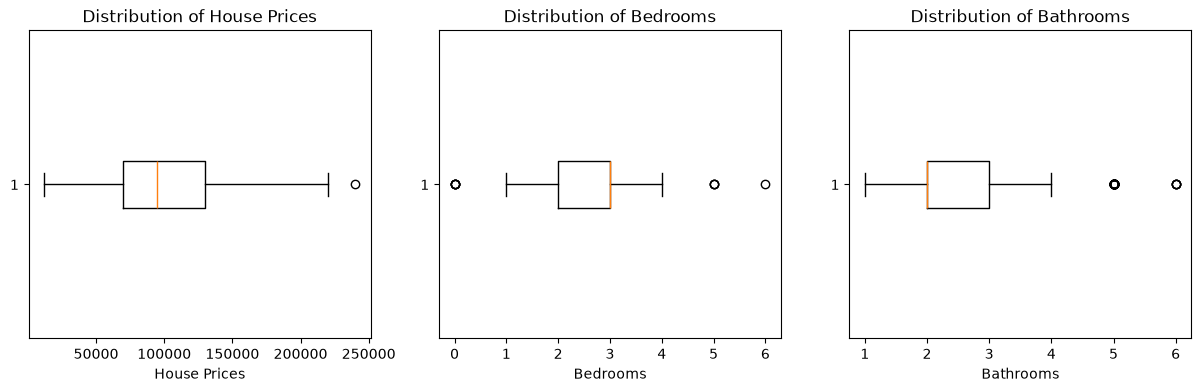

In [3]:
plot_price_distribution(clean, "reports/figures/price_distribution.png")
display(Image("reports/figures/price_distribution.png"))

About half of listings sit above the ~KSh 95,000 median, and the boxes for `Bedrooms` and `Bathrooms` are both centered around 2-3, with a handful of larger outliers pulling each distribution's upper whisker out. Nothing here suggests extreme outliers were missed during cleaning.

## Average price by estate

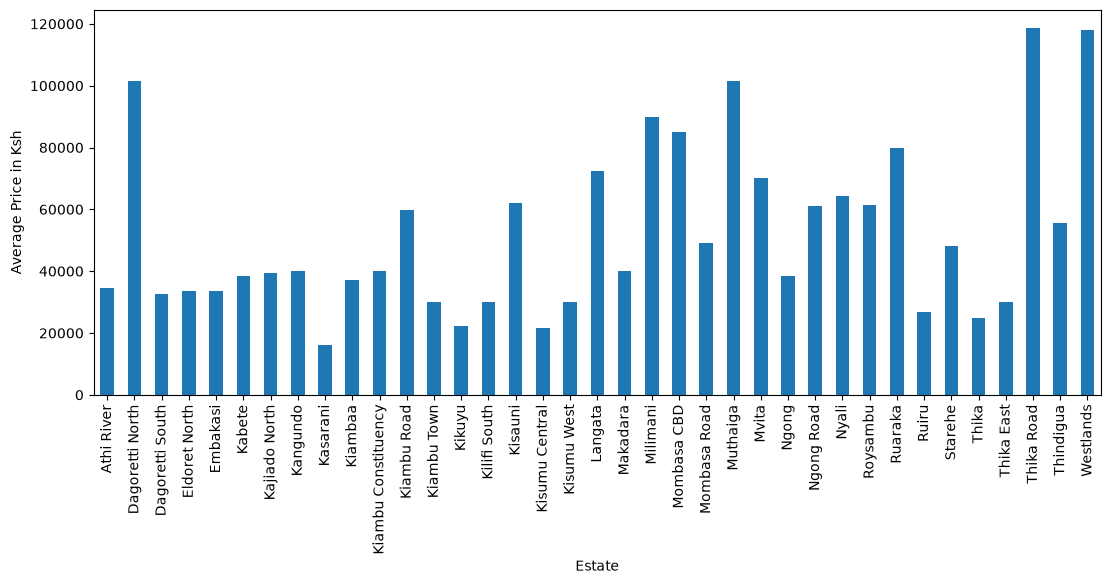

In [4]:
plot_price_by_estate(clean, "reports/figures/price_by_estate.png")
display(Image("reports/figures/price_by_estate.png"))

Thika Road (\~KSh 118,600) and Westlands (\~KSh 118,069) are the two highest-priced estates on average - both roughly 20% above the next tier (Muthaiga, Dagoretti North, both \~KSh 101,500), and more than double the lowest end. Kasarani (\~KSh 16,000) is the most affordable estate by a wide margin, followed by Kisumu Central (\~KSh 21,500) and Kikuyu (\~KSh 22,200). Westlands and Thika Road command a premium, while Kasarani and Kikuyu are among the more affordable options.

## Average price by bedrooms and bathrooms

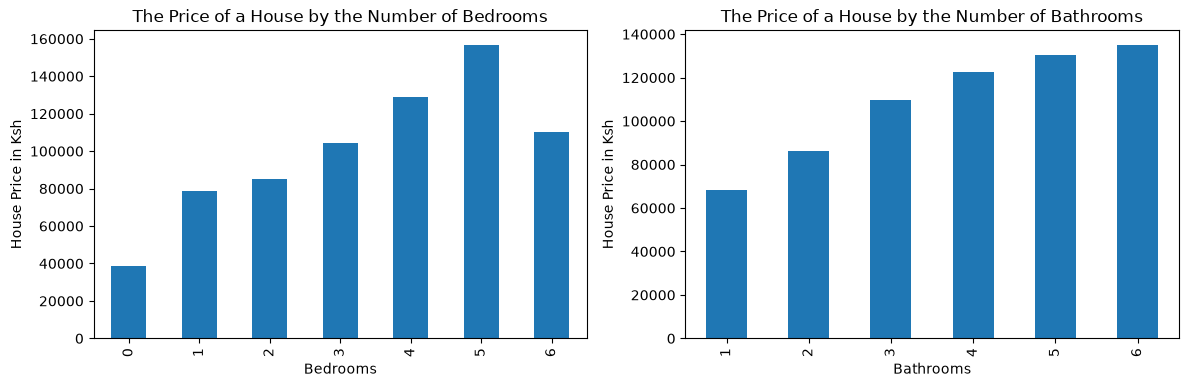

In [5]:
plot_price_by_bedrooms_bathrooms(clean, "reports/figures/price_by_bedrooms_bathrooms.png")
display(Image("reports/figures/price_by_bedrooms_bathrooms.png"))

Average price rises steadily with `Bedrooms` from 0 through 5 (KSh 38,600 - KSh 156,667) - but 6-bedroom listings actually average lower (KSh 110,000) than 5-bedroom ones. It's likely a small-sample effect (6-bedroom listings are rare in this dataset) rather than a genuine market reversal.

`Bathrooms` shows a cleaner, fully monotonic relationship - average price rises at every step from 1 through 6 bathrooms, with no exceptions.